## Прогнозы успеваемости студентов

Цель исследования — разработка модели предсказания итоговых оценок студентов на основе их прошлой успеваемости и ключевых индивидуальных факторов.

## Откроем файл с данными и изучим общую информацию

## Импорт библиотек

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


## Загрузка данных

In [3]:
df=pd.read_csv("student_performance_updated_1000.csv")

In [4]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


## Описание данных

**StudentID** - Уникальный номер студента

**Name** - Имя студента

**Gender** - Пол (Male / Female)

**AttendanceRate** - Посещаемость занятий в %

**StudyHoursPerWeek** - Часов учёбы в неделю

**PreviousGrade** - Оценка за прошлый период

**ExtracurricularActivities** - Количество внеучебных активностей

**ParentalSupport** - Уровень поддержки родителей

**FinalGrade** - Итоговая оценка (целевой признак)

**Study Hours** - Часов учёбы в день

**Attendance (%)** - Альтернативный столбец посещаемости

**Online Classes Taken** - Посещал ли онлайн-занятия

## Изучение нулевых значений, аномалий и дубликатов

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


Как мы видим у нас всего 1000 строк а также существуют значения NAN, а значит их нужно будет заменять. Давайте рассмотрим где и сколько у нас значений  NAN

In [12]:
print(df.isnull().sum())

StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64


Нулевые значения присутсвуют в каждом столбце, запомнили,теперь поищем в нашем датасете аномальные значения

Например невозможны такие значения как посещаемость больше 100 процентов или оценки в минусовом значении и так далее, поищем такие варианты

In [18]:
print(f"Study Hours < 0:          {(df['Study Hours'] < 0).sum()} записей")
print(f"Study Hours > 24:         {(df['Study Hours'] > 24).sum()} записей")
print(f"Attendance (%) > 100:     {(df['Attendance (%)'] > 100).sum()} записей")
print(f"AttendanceRate > 100:     {(df['AttendanceRate'] > 100).sum()} записей")
print(f"FinalGrade > 100:         {(df['FinalGrade'] > 100).sum()} записей")
print(f"FinalGrade < 0:           {(df['FinalGrade'] < 0).sum()} записей")
print(f"PreviousGrade > 100:      {(df['PreviousGrade'] > 100).sum()} записей")
print(f"PreviousGrade < 0:        {(df['PreviousGrade'] < 0).sum()} записей")
print(f"StudyHoursPerWeek < 0:    {(df['StudyHoursPerWeek'] < 0).sum()} записей")
print(f"StudyHoursPerWeek > 168:  {(df['StudyHoursPerWeek'] > 168).sum()} записей")

Study Hours < 0:          10 записей
Study Hours > 24:         0 записей
Attendance (%) > 100:     10 записей
AttendanceRate > 100:     0 записей
FinalGrade > 100:         0 записей
FinalGrade < 0:           0 записей
PreviousGrade > 100:      0 записей
PreviousGrade < 0:        0 записей
StudyHoursPerWeek < 0:    0 записей
StudyHoursPerWeek > 168:  0 записей


Как мы видим аномалий только 20 и заключаются они в отрицательном количестве часах учебы и в посещаемости, которая превышает 100%

In [21]:
print(f"Gender:           {df['Gender'].unique()}")
print(f"ParentalSupport:  {df['ParentalSupport'].unique()}")
print(f"Online Classes:   {df['Online Classes Taken'].unique()}")

Gender:           ['Male' 'Female' nan]
ParentalSupport:  ['High' 'Medium' 'Low' nan]
Online Classes:   [False True nan]


А здесь мы рассмотрели какие значения существуют в тех переменных, где их разновидность не такая большая. Такие как пол или уровень поддержки родителей

In [5]:
print(f"   Полных дублей строк:  {df.duplicated().sum()}")
print(f"   Дублей по StudentID:  {df['StudentID'].duplicated().sum()}")

   Полных дублей строк:  0
   Дублей по StudentID:  83


Поискали дубликаты по так называемым первичным ключам и по полным строкам. Как видим, есть дубликаты StudentID, это надо исправлять

## Исправление нулевых значений, аномалий и дубликатов

Создаем специальный датасет, в котором очистим его от всего лишнего

In [8]:
df_clean = df.copy()

In [9]:
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
dup_id_before = df_clean['StudentID'].duplicated().sum()
df_clean = df_clean.drop_duplicates(subset=['StudentID'], keep='first')

Удалили все дубликаты, а по StudentID оставили только первое вхождение

Теперь будем заменять все аномальные значения на медиану

In [10]:
anomaly_count = ((df_clean['Study Hours'] < 0) | (df_clean['Study Hours'] > 24)).sum()
median_val = df_clean.loc[(df_clean['Study Hours'] >= 0) & (df_clean['Study Hours'] <= 24), 'Study Hours'].median()
df_clean.loc[(df_clean['Study Hours'] < 0) | (df_clean['Study Hours'] > 24), 'Study Hours'] = median_val

anomaly_count = (df_clean['Attendance (%)'] > 100).sum()
median_val = df_clean.loc[df_clean['Attendance (%)'] <= 100, 'Attendance (%)'].median()
df_clean.loc[df_clean['Attendance (%)'] > 100, 'Attendance (%)'] = median_val

anomaly_count = ((df_clean['FinalGrade'] < 0) | (df_clean['FinalGrade'] > 100)).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[(df_clean['FinalGrade'] >= 0) & (df_clean['FinalGrade'] <= 100), 'FinalGrade'].median()
    df_clean.loc[(df_clean['FinalGrade'] < 0) | (df_clean['FinalGrade'] > 100), 'FinalGrade'] = median_val

anomaly_count = ((df_clean['PreviousGrade'] < 0) | (df_clean['PreviousGrade'] > 100)).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[(df_clean['PreviousGrade'] >= 0) & (df_clean['PreviousGrade'] <= 100), 'PreviousGrade'].median()
    df_clean.loc[(df_clean['PreviousGrade'] < 0) | (df_clean['PreviousGrade'] > 100), 'PreviousGrade'] = median_val

anomaly_count = ((df_clean['StudyHoursPerWeek'] < 0) | (df_clean['StudyHoursPerWeek'] > 168)).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[(df_clean['StudyHoursPerWeek'] >= 0) & (df_clean['StudyHoursPerWeek'] <= 168), 'StudyHoursPerWeek'].median()
    df_clean.loc[(df_clean['StudyHoursPerWeek'] < 0) | (df_clean['StudyHoursPerWeek'] > 168), 'StudyHoursPerWeek'] = median_val

anomaly_count = (df_clean['AttendanceRate'] > 100).sum()
if anomaly_count > 0:
    median_val = df_clean.loc[df_clean['AttendanceRate'] <= 100, 'AttendanceRate'].median()
    df_clean.loc[df_clean['AttendanceRate'] > 100, 'AttendanceRate'] = median_val

Отлично, а теперь тоже самое с пропусками и значениями NAN

In [11]:
num_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
            'ExtracurricularActivities', 'FinalGrade',
            'Study Hours', 'Attendance (%)']

for col in num_cols:
    missing_before = df_clean[col].isnull().sum()
    if missing_before > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

missing_before = df_clean['Gender'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['Gender'].mode()[0]
    df_clean['Gender'] = df_clean['Gender'].fillna(mode_val)

num_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
            'ExtracurricularActivities', 'FinalGrade',
            'Study Hours', 'Attendance (%)']

for col in num_cols:
    missing_before = df_clean[col].isnull().sum()
    if missing_before > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

missing_before = df_clean['Gender'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['Gender'].mode()[0]
    df_clean['Gender'] = df_clean['Gender'].fillna(mode_val)

missing_before = df_clean['ParentalSupport'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['ParentalSupport'].mode()[0]
    df_clean['ParentalSupport'] = df_clean['ParentalSupport'].fillna(mode_val)

missing_before = df_clean['Online Classes Taken'].isnull().sum()
if missing_before > 0:
    mode_val = df_clean['Online Classes Taken'].mode()[0]
    df_clean['Online Classes Taken'] = df_clean['Online Classes Taken'].fillna(mode_val)

C:\Users\user\AppData\Local\Temp\ipykernel_15904\2796445648.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Online Classes Taken'] = df_clean['Online Classes Taken'].fillna(mode_val)


## Визуализация и Графики

Теперь самое время построить графики и рассмотреть важность признаков для этого датасета

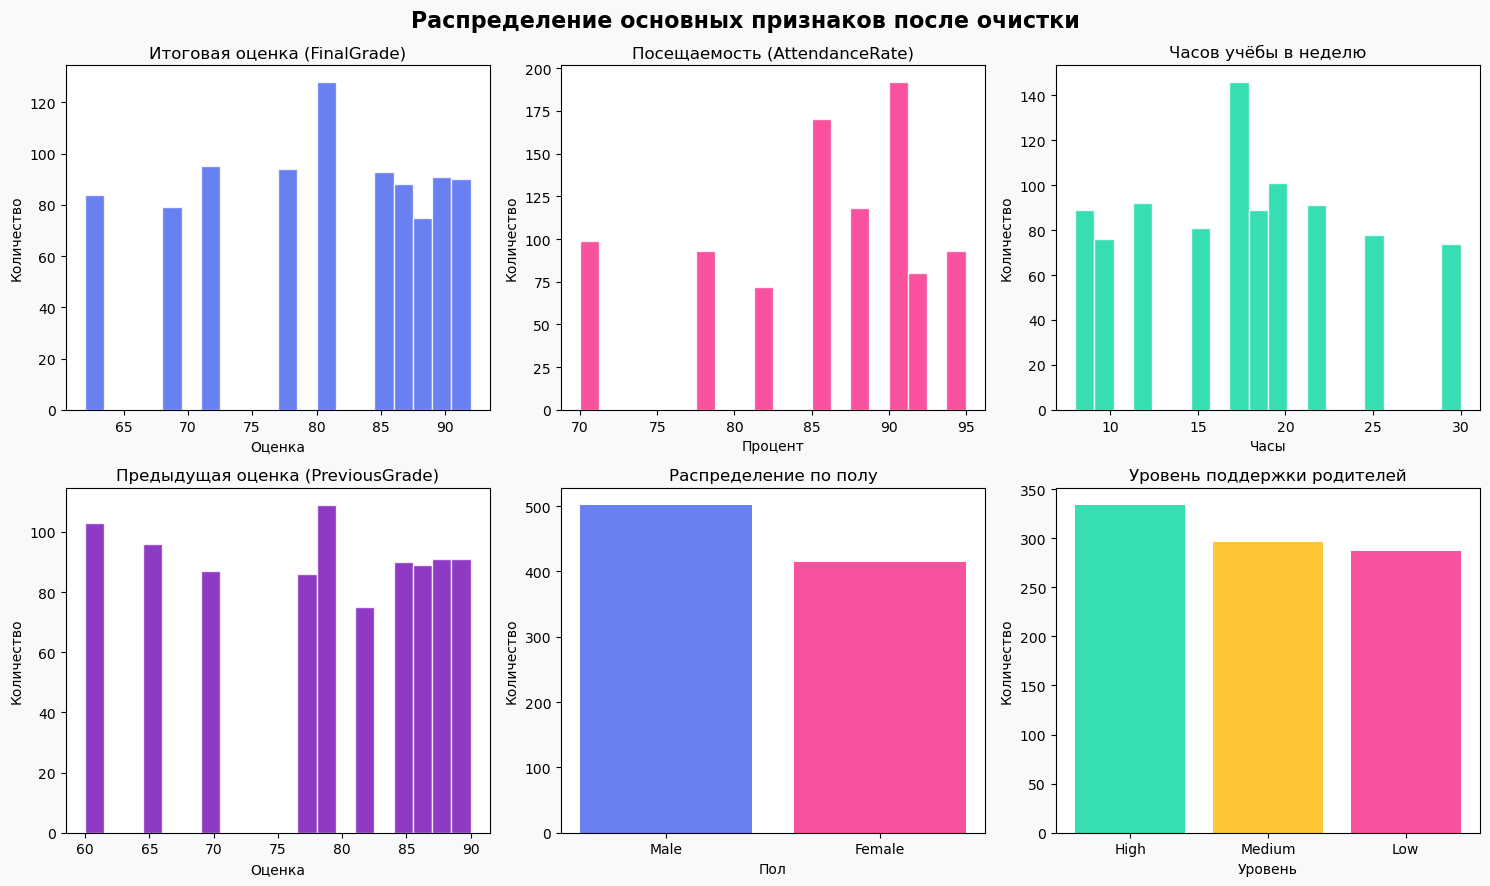

In [17]:
plt.rcParams['figure.facecolor'] = '#F8F9FA'
plt.rcParams['axes.facecolor'] = '#FFFFFF'
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Распределение основных признаков после очистки', fontsize=16, fontweight='bold')

axes[0, 0].hist(df_clean['FinalGrade'], bins=20, color='#4361EE', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Итоговая оценка (FinalGrade)')
axes[0, 0].set_xlabel('Оценка')
axes[0, 0].set_ylabel('Количество')

axes[0, 1].hist(df_clean['AttendanceRate'], bins=20, color='#F72585', alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Посещаемость (AttendanceRate)')
axes[0, 1].set_xlabel('Процент')
axes[0, 1].set_ylabel('Количество')

axes[0, 2].hist(df_clean['StudyHoursPerWeek'], bins=20, color='#06D6A0', alpha=0.8, edgecolor='white')
axes[0, 2].set_title('Часов учёбы в неделю')
axes[0, 2].set_xlabel('Часы')
axes[0, 2].set_ylabel('Количество')

axes[1, 0].hist(df_clean['PreviousGrade'], bins=20, color='#7209B7', alpha=0.8, edgecolor='white')
axes[1, 0].set_title('Предыдущая оценка (PreviousGrade)')
axes[1, 0].set_xlabel('Оценка')
axes[1, 0].set_ylabel('Количество')

gender_counts = df_clean['Gender'].value_counts()
axes[1, 1].bar(gender_counts.index, gender_counts.values, color=['#4361EE', '#F72585'], alpha=0.8)
axes[1, 1].set_title('Распределение по полу')
axes[1, 1].set_xlabel('Пол')
axes[1, 1].set_ylabel('Количество')

ps_counts = df_clean['ParentalSupport'].value_counts()
axes[1, 2].bar(ps_counts.index, ps_counts.values, color=['#06D6A0', '#FFB703', '#F72585'], alpha=0.8)
axes[1, 2].set_title('Уровень поддержки родителей')
axes[1, 2].set_xlabel('Уровень')
axes[1, 2].set_ylabel('Количество')

plt.tight_layout()
plt.show()

Датасет сбалансированный по полу и уровню поддержки родителей. Большинство студентов — успешные (высокие оценки + высокая посещаемость).

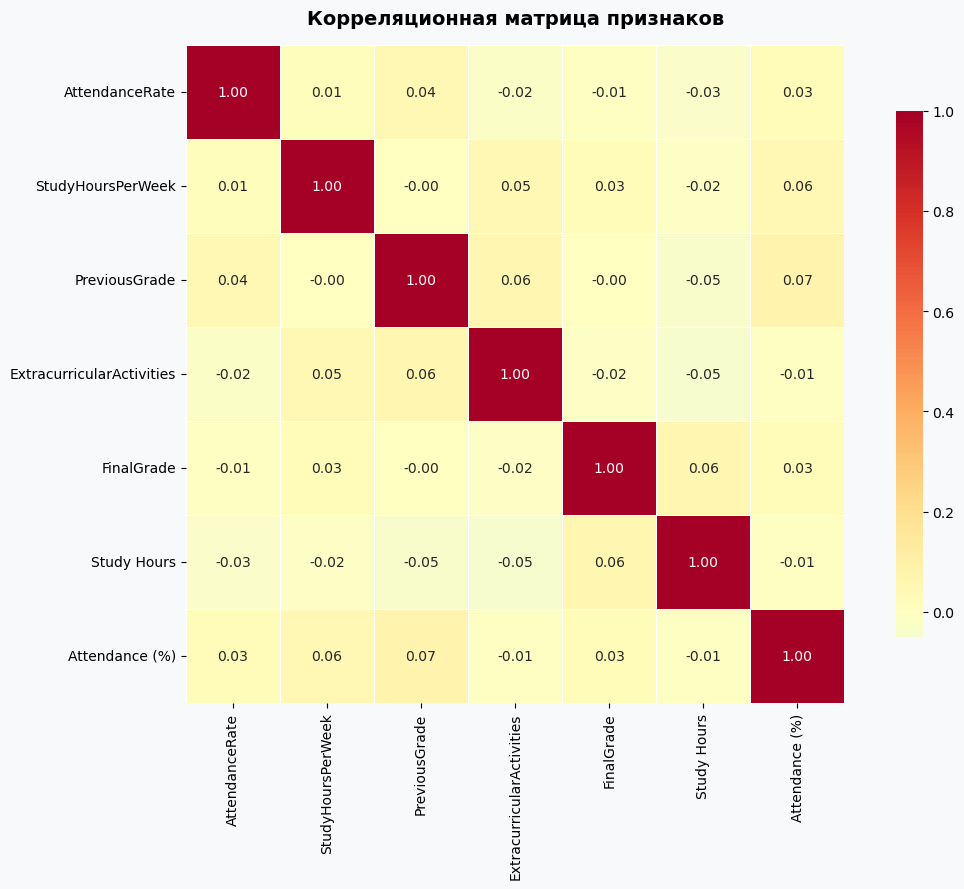

In [19]:

num_data = df_clean.select_dtypes(include=['float64', 'int64']).drop(columns=['StudentID'], errors='ignore')
corr_matrix = num_data.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Корреляционная матрица признаков', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



Линейные модели (например, линейная регрессия) будут плохо работать на этих данных. Нужны нелинейные методы Random Forest или комбинации признаков. Успех студента зависит от комплексного взаимодействия многих факторов, а не от одного-двух доминирующих.

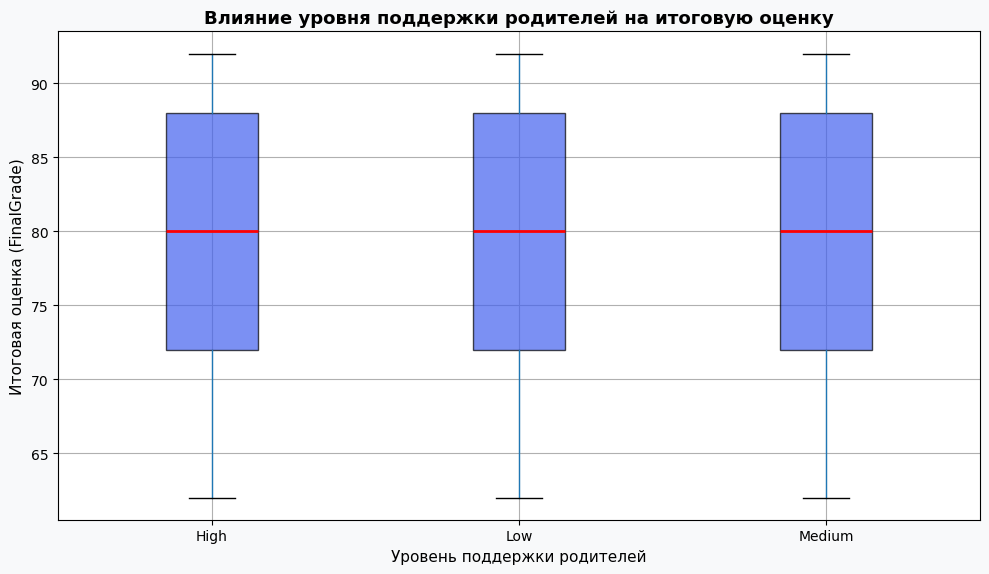

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
df_clean.boxplot(column='FinalGrade', by='ParentalSupport', ax=ax,
                 patch_artist=True, 
                 boxprops=dict(facecolor='#4361EE', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax.set_title('Влияние уровня поддержки родителей на итоговую оценку', fontsize=13, fontweight='bold')
ax.set_xlabel('Уровень поддержки родителей', fontsize=11)
ax.set_ylabel('Итоговая оценка (FinalGrade)', fontsize=11)
plt.suptitle('') 
plt.tight_layout()
plt.show()


Уровень поддержки родителей НЕ влияет на итоговую оценку. Студенты с высокой, средней и низкой поддержкой показывают статистически идентичные результаты. Возможные причины: либо поддержка родителей измерена некорректно (субъективно), либо в студенческом возрасте влияние родителей уже минимально.

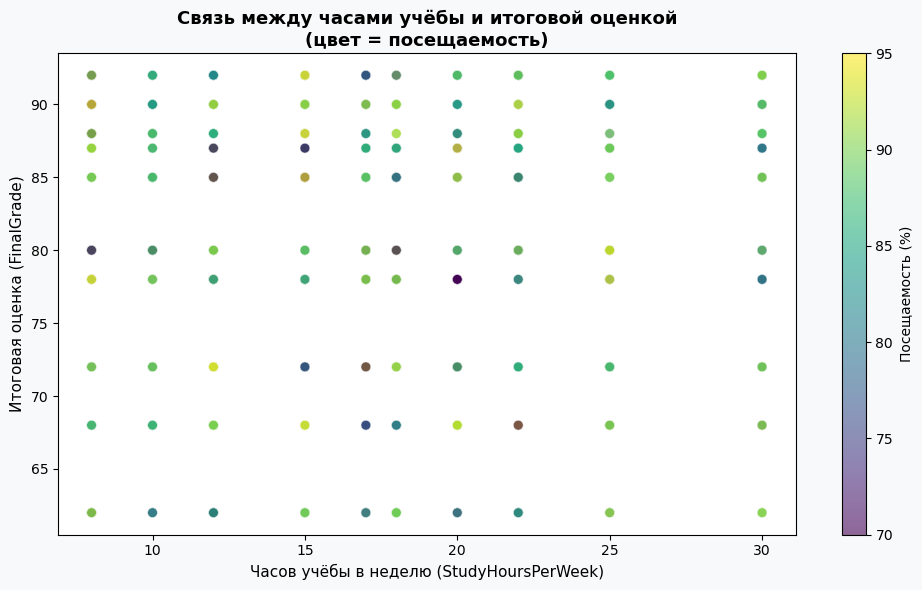

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_clean['StudyHoursPerWeek'], df_clean['FinalGrade'],
                     c=df_clean['AttendanceRate'], cmap='viridis',
                     alpha=0.6, s=50, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Часов учёбы в неделю (StudyHoursPerWeek)', fontsize=11)
ax.set_ylabel('Итоговая оценка (FinalGrade)', fontsize=11)
ax.set_title('Связь между часами учёбы и итоговой оценкой\n(цвет = посещаемость)',
             fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Посещаемость (%)', fontsize=10)
plt.tight_layout()
plt.show()

Часы учёбы помогают, но не решают всё. Ключевой фактор — комбинация часов учёбы + высокая посещаемость. Студент может учиться 30 часов в неделю, но если пропускает занятия — результат посредственный. И наоборот: 15 часов + 95% посещаемость = хороший результат.